In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import time
from scipy.stats import poisson
from scipy.stats import nbinom

In [2]:
len_fit = 500
fitness = np.zeros(len_fit) #initiating array with lots of extra entries
k_star = 50 #threshold
for i in range(len_fit):
    if i < k_star:
        fitness[i] = 1 + i*0.05
    else:
        fitness[i] = 1 + k_star*0.05

In [3]:
rng = np.random.default_rng()

In [6]:
#fitness = np.ones(len_fit)*3
#fitness[0] = 1
cells = np.zeros(len_fit)
k0 = 100
cells[k0] = 1
total_pop = 1

while total_pop < 100_000:
    rates = cells*fitness
    k_ind = rng.choice(len_fit, p = rates/np.sum(rates))
    k1 = rng.binomial(2*k_ind, 0.5)
    k2 = 2*k_ind - k1
    #print(k_ind, k1, k2)
    cells[k_ind] -= 1
    cells[k1] += 1
    cells[k2] += 1
    total_pop += 1

Text(0, 0.5, 'cell count')

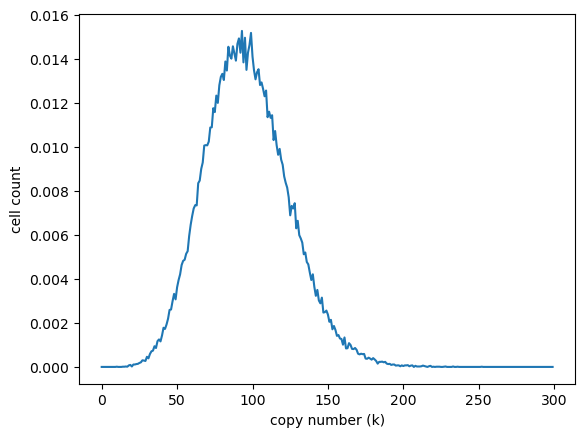

In [7]:
x = np.arange(300)
plt.plot(x, cells[0:300]/100_000)
plt.xlabel('copy number (k)')
plt.ylabel('cell count')

#plt.plot(x, nbinom.pmf(x, 40, 0.3))

Text(0, 0.5, 'cell count')

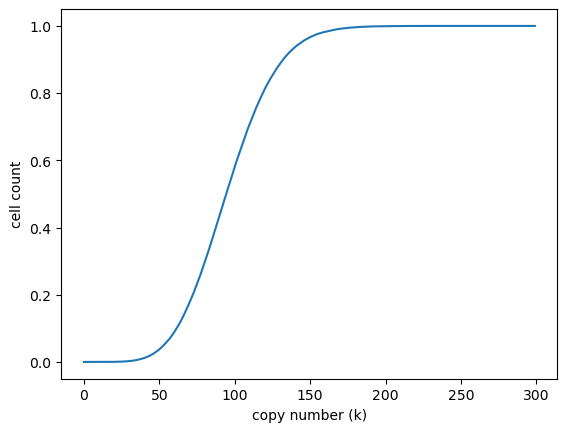

In [8]:
x = np.arange(300)
plt.plot(x, np.cumsum(cells[0:300]/100_000))
plt.xlabel('copy number (k)')
plt.ylabel('cell count')

In [9]:
def create_fitness_array(k_star, alpha, array_len=500): 
    fitness = np.zeros(array_len)
    for i in range(len(fitness)):
        if i < k_star:
            fitness[i] = 1 + i*alpha
        else:
            fitness[i] = 1 + k_star*alpha
    return fitness

def one_run(fitness_array, k0 : int = 100, max_cells : int = 100_000):
    ''' Performs one run of the simulation
    fitness: numpy array of fitness of each copy number. The k-th entry represents the fitness of a cell with k copies of ecDNA. 
    k0: the number of copies in the initiating cell. 
    max_cells: population at which to stop the simulation
    '''
    #print(fitness_array)
    rng = np.random.default_rng()
    array_len = len(fitness_array)
    cells = np.zeros(array_len)
    cells[k0] = 1
    total_pop = 1

    while total_pop < max_cells:
        rates = cells*fitness_array
        k_ind = rng.choice(len_fit, p = rates/np.sum(rates))
        #print(k_ind)
        k1 = rng.binomial(2*k_ind, 0.5)
        k2 = 2*k_ind - k1
        #print(k1, k2, 2*k_ind)

        cells[k_ind] -= 1
        cells[k1] += 1
        cells[k2] += 1
        total_pop += 1
            
    return cells

def many_runs(num_runs, fitness_array, k0 = 100, max_cells = 100_000):
    cell_pops = Parallel(n_jobs = -1)(delayed(one_run)(fitness_array, k0, max_cells) for run in range(num_runs)) 
    return np.array(cell_pops)

In [10]:
fit = create_fitness_array(100, 1)
testing = np.zeros((10, 500))
for i in range(10):
    testing[i, :] = one_run(fit, 10, 100_000)

KeyboardInterrupt: 

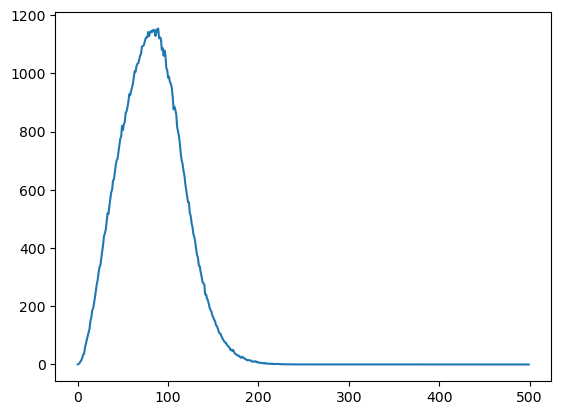

In [222]:
plt.plot(np.arange(500), np.mean(testing, axis = 0))

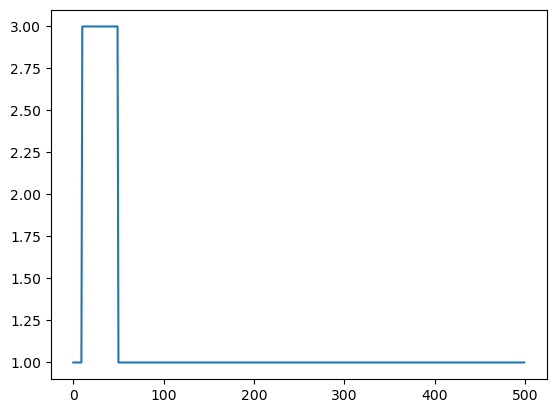

In [269]:
step_fit = np.ones(500)
for i in range(10, 50):
    step_fit[i] = 3
plt.plot(step_fit)

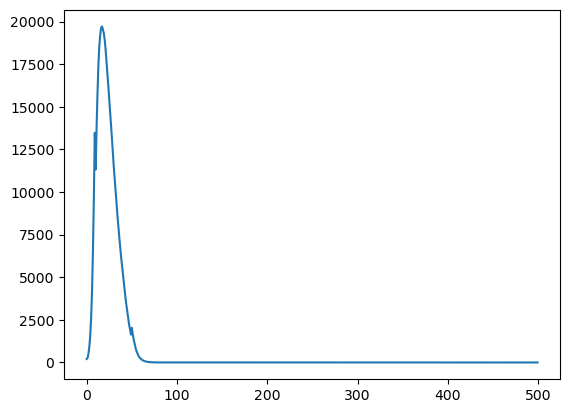

In [270]:
testing = np.zeros((10, 500))
for i in range(10):
    testing[i, :] = one_run(step_fit, 10, 5_00_000)
plt.plot(np.arange(500), np.mean(testing, axis = 0))

In [13]:
fit = create_fitness_array(100, 0.1)
t1 = time.time()
test = many_runs(1000, fit, 100, 100_000)
t2 = time.time()
print(t2-t1)

37.00417375564575


In [12]:
fit = create_fitness_array(100, 0.1)
t1 = time.time()
test = many_runs(num_runs = 100, fitness_array = fit, k0 = 50, max_cells = 1000_000)
t2 = time.time()
print(t2-t1)

45.20935320854187


In [ ]:
#for saving data-- don't run again
alpha_list = np.linspace(0.2, 1, 9)
for alpha in alpha_list: 
    fit = create_fitness_array(k_star = 50, alpha = alpha)
    out = many_runs(num_runs = 1000, fitness_array = fit, 100, 100_000)
    np.savetxt(f'ks_100_alpha_{alpha:2f}.csv', out)

In [57]:
np.linspace(0.1, 1, 10)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [58]:
alpha_list = np.linspace(0.1, 1, 10)
for alpha in alpha_list: 
    fit = create_fitness_array(50, alpha)
    out = many_runs(1000, fit, 100, 1_00_000)
    np.savetxt(f'data/ks_50_alpha_{alpha:.2f}_k0_100.csv', out)

In [14]:
import glob
files = glob.glob('ks*.csv')

In [15]:
test_mean = np.mean(test, axis = 0)
test_std = np.std(test, axis = 0)

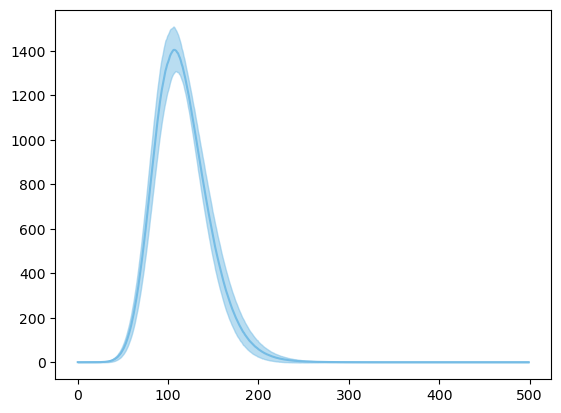

In [16]:
test_mean = np.mean(test, axis = 0)
test_std = np.std(test, axis = 0)
plt.fill_between(np.arange(500), test_mean - test_std, test_mean + test_std, color = '#75BCE5', alpha = 0.5)
plt.plot(np.arange(500), test_mean, color = '#75BCE5')

### Comparing results from author's simulation to my simulation

In [17]:
#comparing results from my simulation to the author's simulation
data = np.loadtxt('NonNeutralSummaryPC3.txt')

In [79]:
len_fit = 500
fit = np.ones(len_fit)*3
fit[0] = 1
cells = np.zeros(len(fit))
k0 = 50
cells[k0] = 1
total_pop = 1

rng = np.random.default_rng()
while total_pop < 100_000:
    rates = cells*fit
    k_ind = rng.choice(len_fit, p = rates/np.sum(rates))
    k1 = rng.binomial(2*k_ind, 0.5)
    k2 = 2*k_ind - k1
    #print(k_ind, k1, k2)
    cells[k_ind] -= 1
    cells[k1] += 1
    cells[k2] += 1
    total_pop += 1

In [89]:
fit = np.ones(len_fit)*3
fit[0] = 1
comparison_test = many_runs(10, fit, k0 = 10)

In [82]:
data_plot = np.zeros((10, 309))
for i in range(10):
    row = np.histogram(data[i,:], bins = np.arange(0, 310))[0]
    data_plot[i] = row

In [83]:
np.count_nonzero(data)

1000000

In [84]:
data.shape

(10, 100000)

In [85]:
np.count_nonzero(data)

1000000

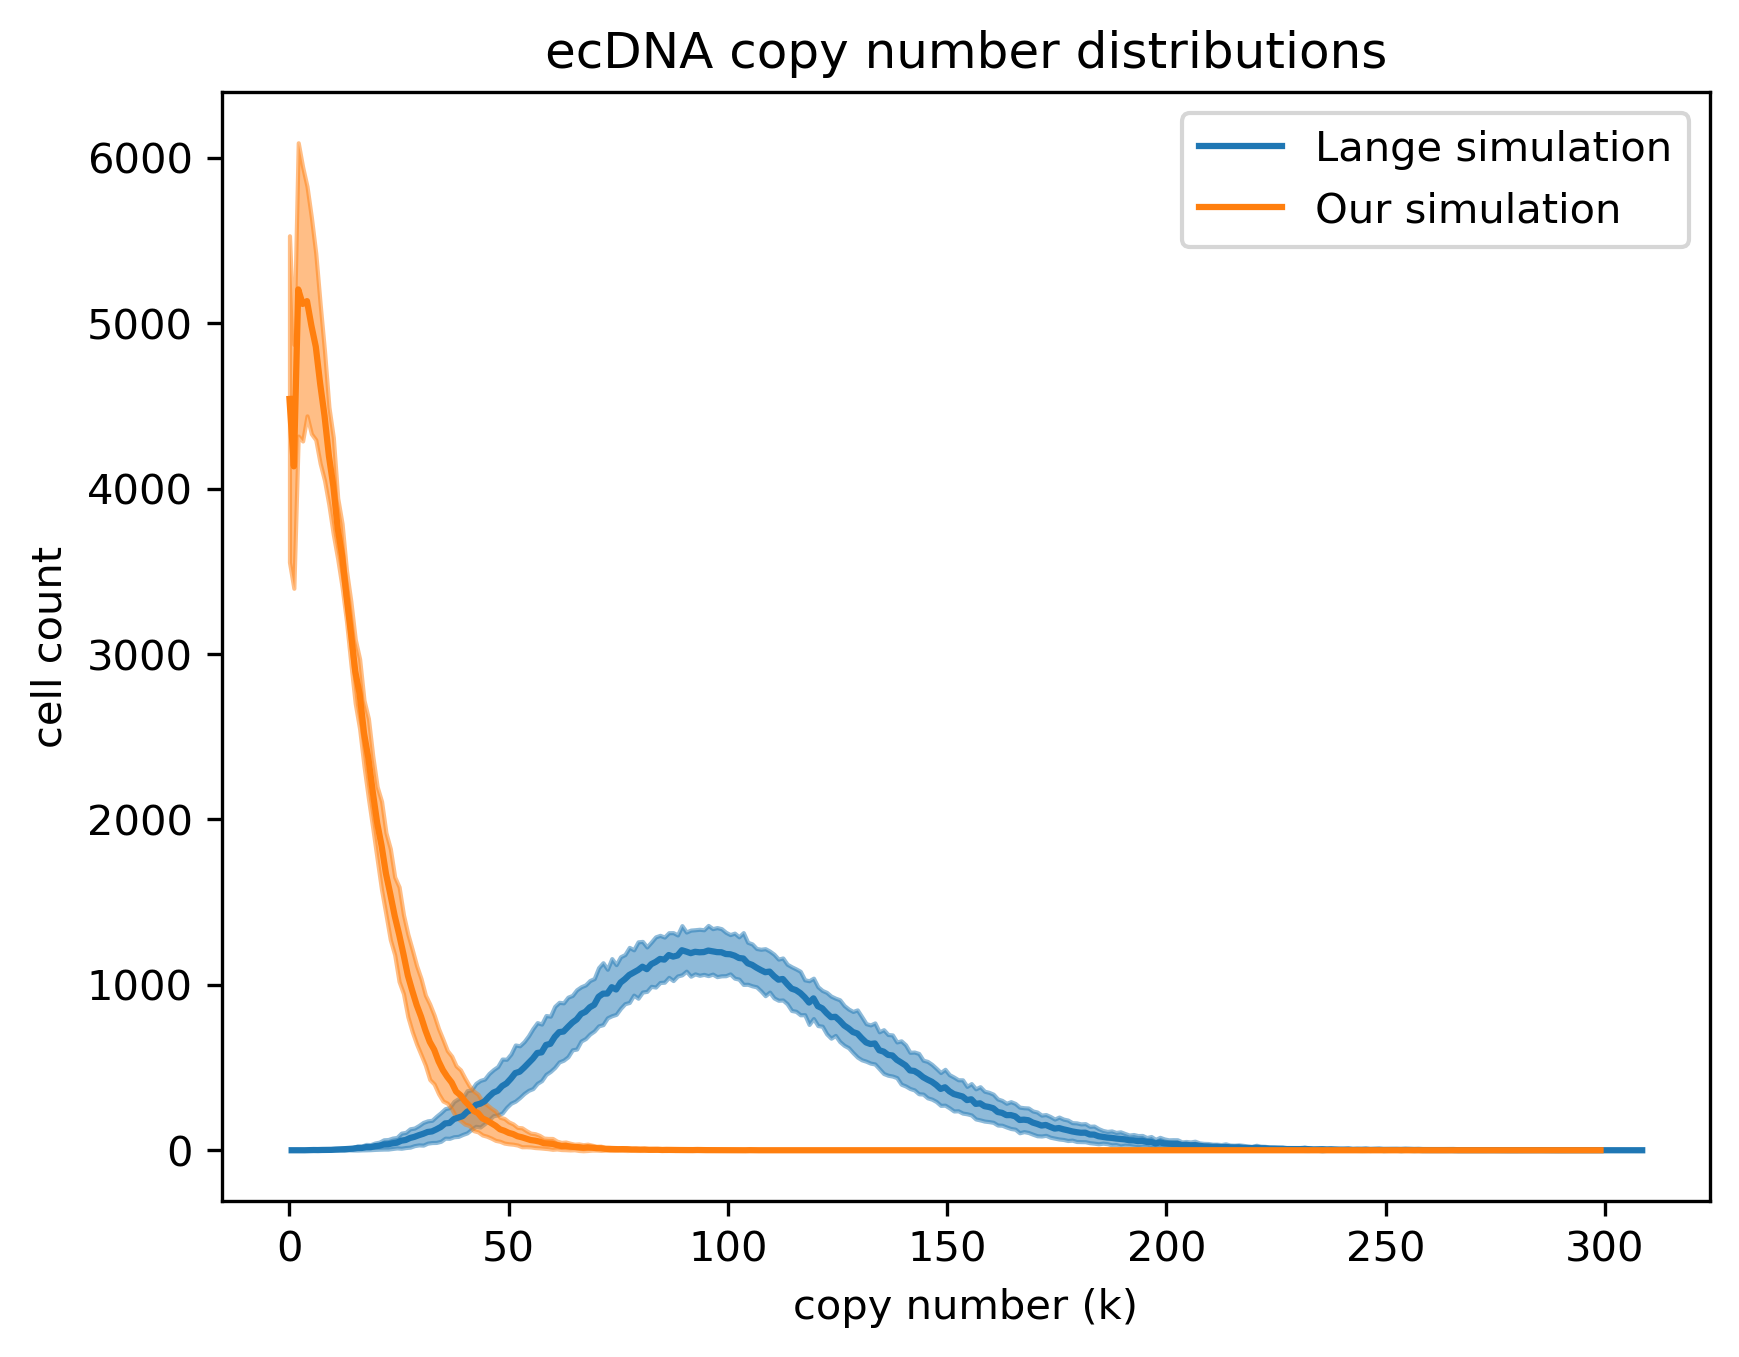

In [90]:
#plt.hist(data[0, :], bins = 300, histtype = 'step');
plt.subplots(dpi = 300)
plt.plot(np.arange(0.5, 309.5, 1), np.mean(data_plot, axis = 0), color = 'tab:blue', label = 'Lange simulation')
plt.fill_between(np.arange(0.5, 309.5, 1), np.mean(data_plot, axis = 0) - np.std(data_plot, axis = 0)
                 , np.mean(data_plot, axis = 0) + np.std(data_plot, axis = 0), color = 'tab:blue', alpha = 0.5)
plt.plot(np.arange(300), np.mean(comparison_test, axis = 0)[0:300], color = 'tab:orange', label = 'Our simulation')
plt.fill_between(np.arange(300), (np.mean(comparison_test, axis = 0) - np.std(comparison_test, axis = 0))[0:300], 
                 (np.mean(comparison_test, axis = 0) + np.std(comparison_test, axis = 0))[:300], color = 'tab:orange', alpha = 0.5)
plt.xlabel('copy number (k)')
plt.ylabel('cell count')
plt.title('ecDNA copy number distributions')
plt.legend()
#plt.savefig('/Users/rmgrover/Documents/GradCoursework/AMATH_536/AMATH536_FinalProject/LangeComparison.pdf', bbox_inches = 'tight', dpi = 400)

In [78]:
neutral_fit = create_fitness_array(100, 0)
neutral_test = many_runs(10, neutral_fit, 100, 10_000_000)

KeyboardInterrupt: 

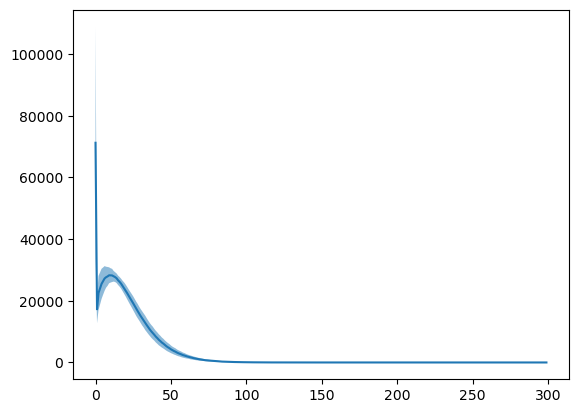

In [77]:
neutral_mean = np.mean(neutral_test, axis = 0)[:300]
neutral_std = np.std(neutral_test, axis = 0)[:300]
t = np.arange(300)
plt.plot(t, neutral_mean)
plt.fill_between(t, neutral_mean - neutral_std, neutral_mean + neutral_std, alpha =0.5)

In [27]:
neutral_data = np.loadtxt('NonNeutralSummary_NoSelection.txt')

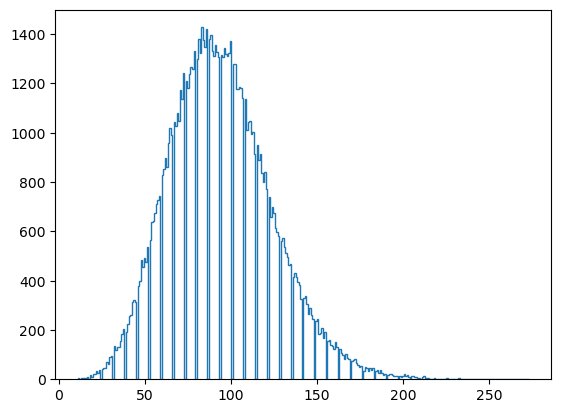

In [28]:
plt.hist(neutral_data[0, :], bins = 300, histtype = 'step');

### Data analysis and plotting

In [66]:
import glob
files = glob.glob('data/ks_100*.csv')
files.sort()

In [67]:
files

['data/ks_100_alpha_0.1.csv',
 'data/ks_100_alpha_0.2.csv',
 'data/ks_100_alpha_0.3.csv',
 'data/ks_100_alpha_0.4.csv',
 'data/ks_100_alpha_0.5.csv',
 'data/ks_100_alpha_0.6.csv',
 'data/ks_100_alpha_0.7.csv',
 'data/ks_100_alpha_0.8.csv',
 'data/ks_100_alpha_0.9.csv',
 'data/ks_100_alpha_1.0.csv']

In [70]:
sims = []
alpha_list = np.arange(0.1, 1.1, 0.1)
for i in range(len(files)):
    alpha = alpha_list[i]
    sims.append(np.loadtxt(files[i]))

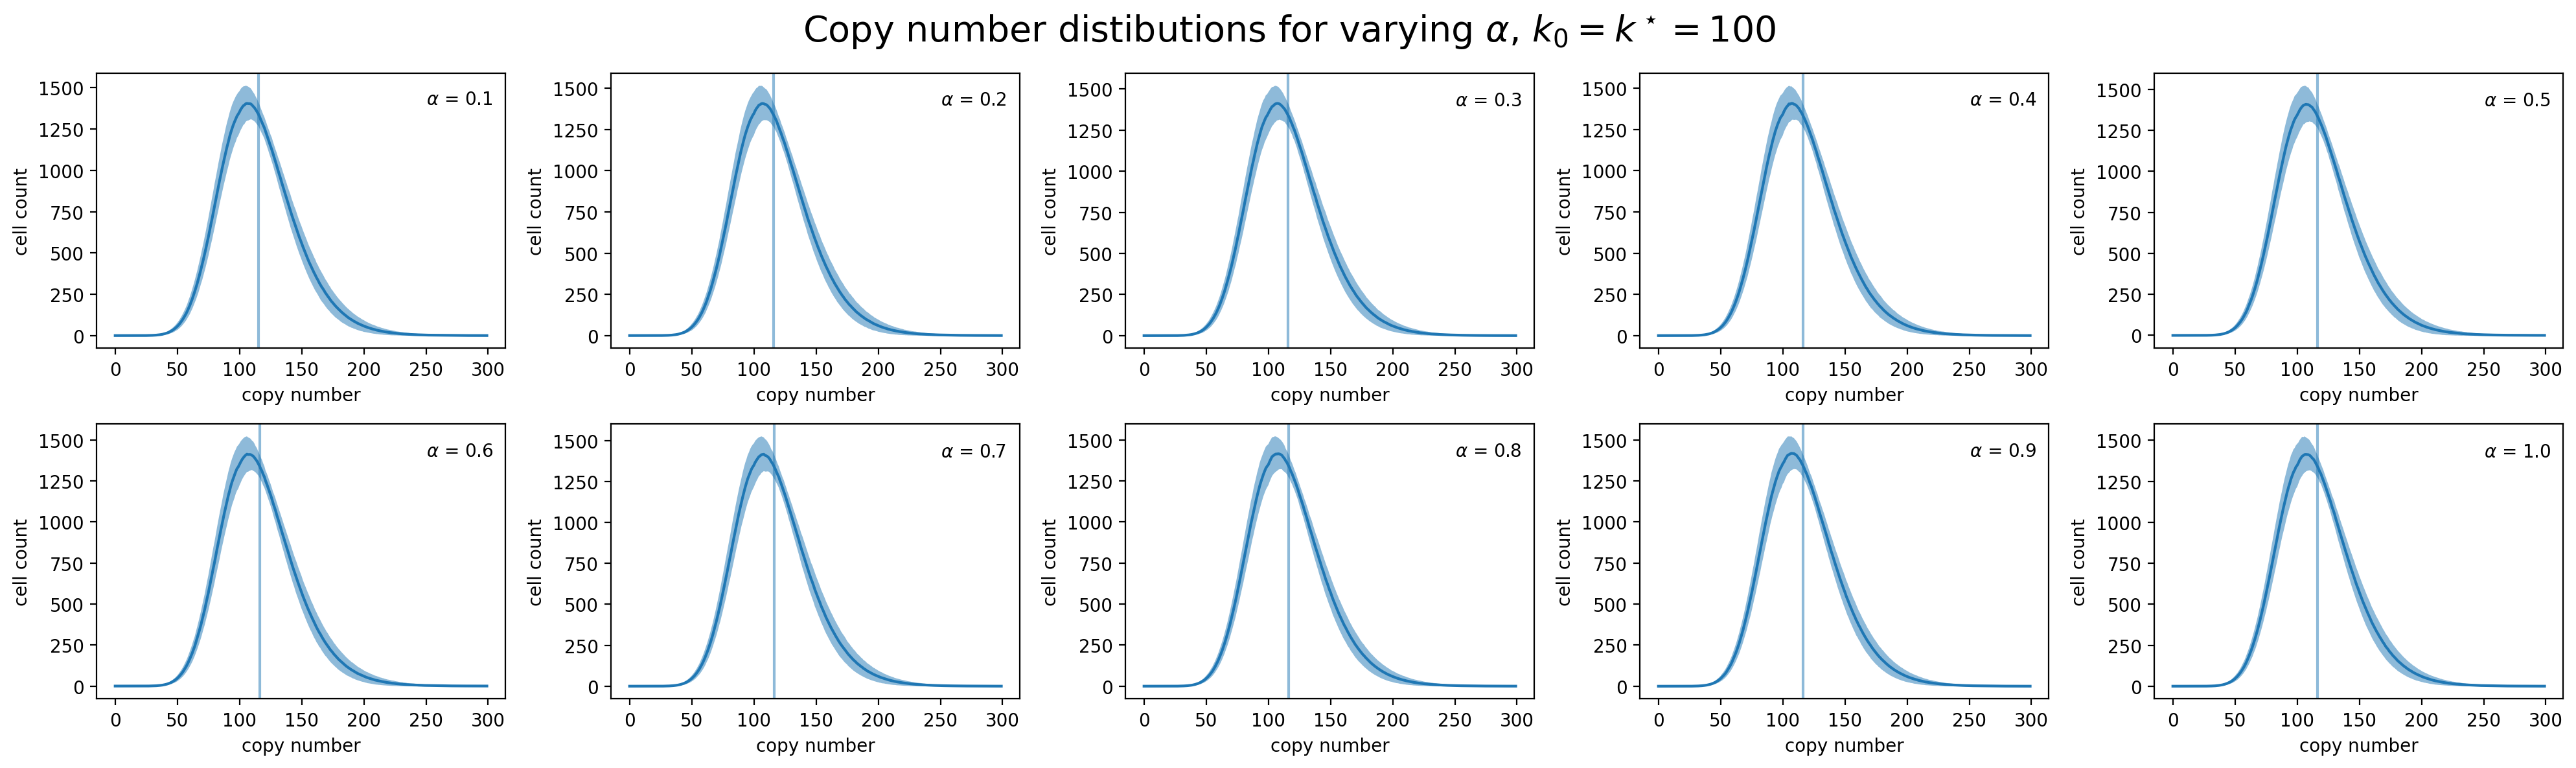

In [75]:
fig, axes = plt.subplots(2, 5, figsize = (20, 6), dpi = 200)
x = np.arange(0, 300)
alpha_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for i, ax in enumerate(axes.flat):
    #print(i)
    alpha = alpha_list[i]
    y = sims[i].copy()
    y = y[:, 0:300]
    mean = np.mean(y, axis = 0)
    std = np.std(y, axis = 0)
    ax.plot(x, mean)
    ax.fill_between(x, mean - std, mean+std, alpha = 0.5)
    weights = np.sum(y, axis=0)
    avg = np.average(np.arange(300), weights=weights)
    #print(avg)
    ax.axvline(avg, alpha = 0.5)
    ax.set_xlabel('copy number')
    ax.set_ylabel('cell count')
    ax.text(250, 1400, fr'$\alpha$ = {alpha}')
fig.suptitle(r'Copy number distibutions for varying $\alpha$, $k_0 = k^\star = 100$', fontsize = 20)
plt.tight_layout()
#plt.savefig('copy_number_dists_ks100.pdf', bbox_inches = 'tight', dpi = 400)

113.65548732


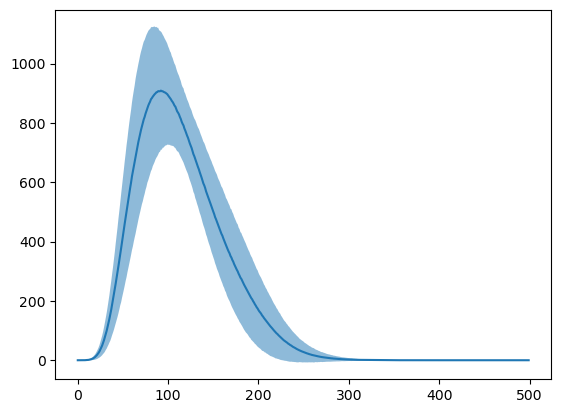

In [38]:
data1 = np.loadtxt('data/ks_50_alpha_0.1.csv')
mean = np.mean(data1, axis = 0)
std = np.std(data1, axis = 0)
x = np.arange(500)
plt.plot(np.arange(500), mean)
plt.fill_between(x, mean-std, mean+std, alpha = 0.5)
weights = np.sum(data1, axis=0)
k_vals = np.arange(500)
avg = np.average(k_vals, weights=weights)
print(avg)

In [39]:
data1 = np.loadtxt(files[0])
data2 = np.loadtxt(files[1])

In [40]:
np.isclose(data1,data2) #same in about half the entries-- probably the 0 entries

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [59]:
files = glob.glob('data/ks_50*.csv')
files.sort()

In [60]:
len(files)

10

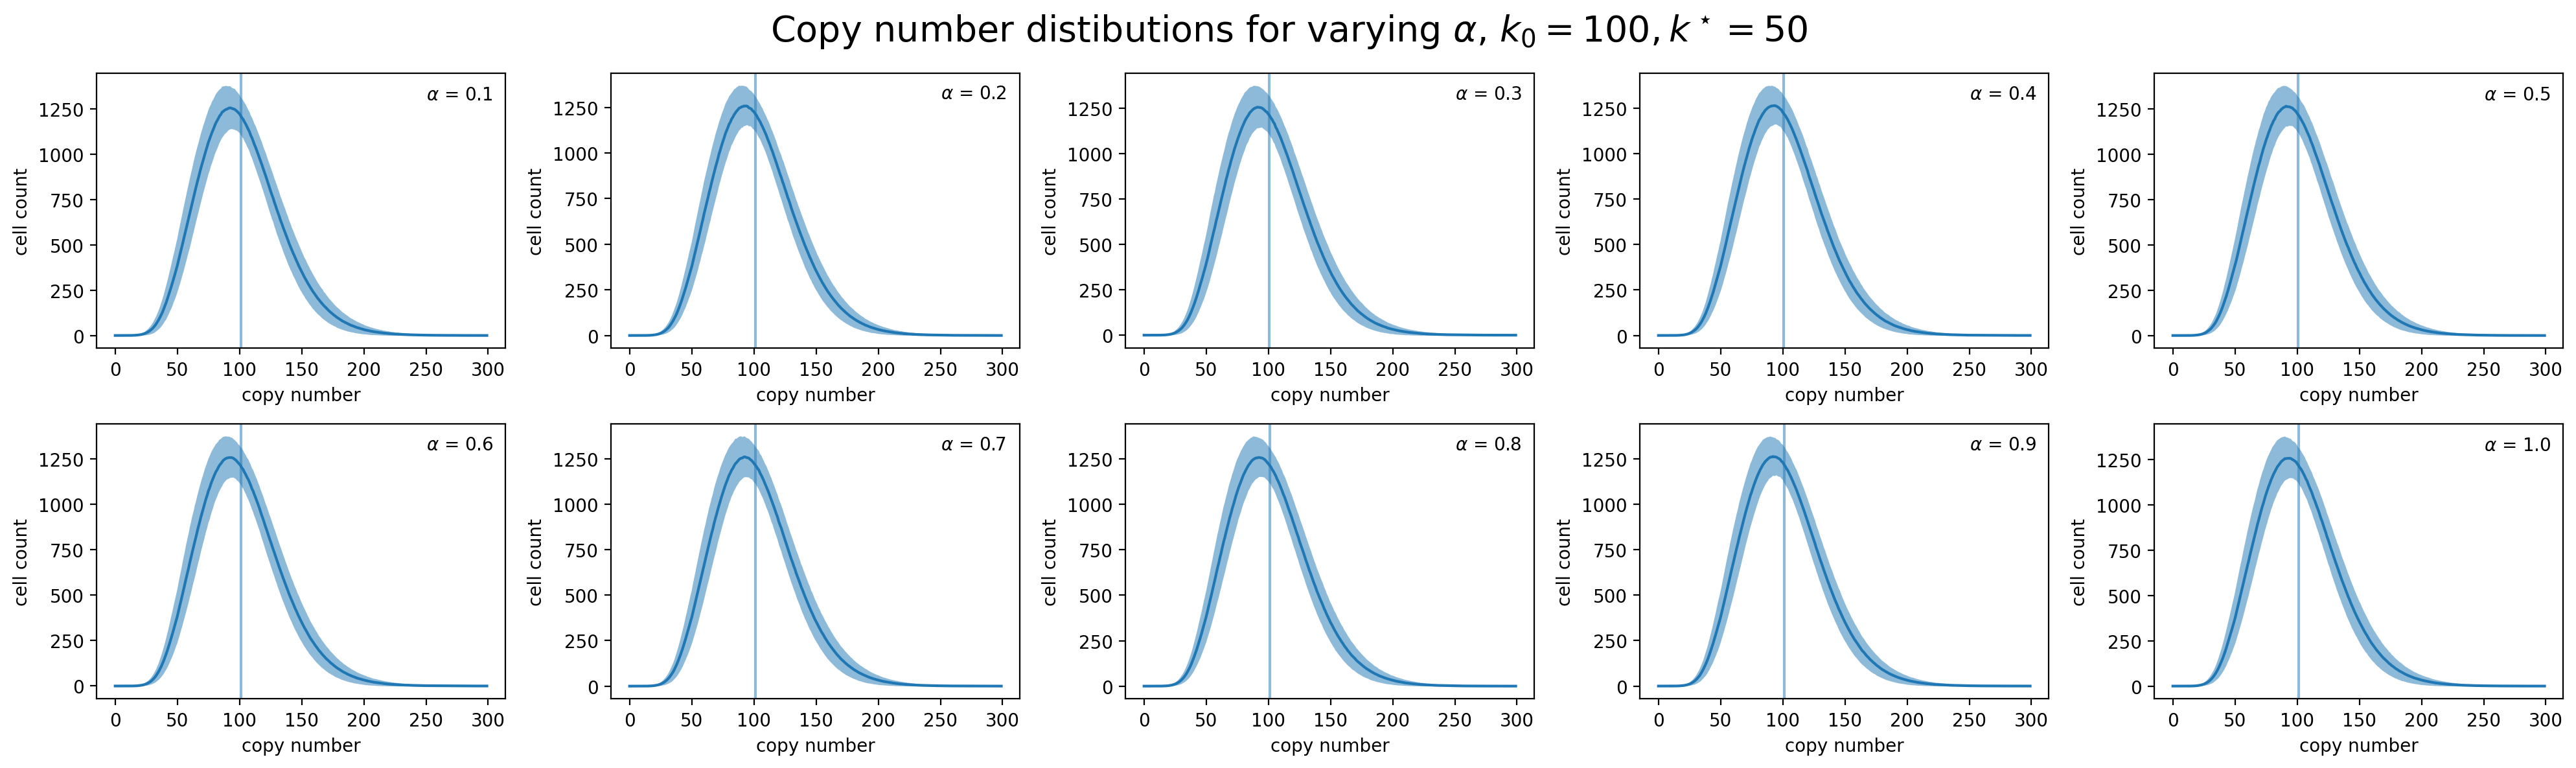

In [65]:
sims = []
alpha_list = np.arange(0.1, 1.1, 0.1)
for i in range(len(files)):
    alpha = alpha_list[i]
    sims.append(np.loadtxt(files[i]))
    
fig, axes = plt.subplots(2, 5, figsize = (20, 6), dpi = 200)
x = np.arange(0, 300)
alpha_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for i, ax in enumerate(axes.flat):
    #print(i)
    alpha = alpha_list[i]
    y = sims[i].copy()
    y = y[:, 0:300]
    mean = np.mean(y, axis = 0)
    std = np.std(y, axis = 0)
    ax.plot(x, mean)
    ax.fill_between(x, mean - std, mean+std, alpha = 0.5)
    weights = np.sum(y, axis=0)
    avg = np.average(np.arange(300), weights=weights)
    #print(avg)
    ax.axvline(avg, alpha = 0.5)
    ax.set_xlabel('copy number')
    ax.set_ylabel('cell count')
    ax.text(250, 1300, fr'$\alpha$ = {alpha}')
fig.suptitle(r'Copy number distibutions for varying $\alpha$, $k_0 = 100, k^\star = 50$', fontsize = 20)
plt.tight_layout()
#plt.savefig('copy_number_dists_ks50.pdf', bbox_inches = 'tight', dpi = 400)